In [1]:
cd "C:\Users\mikym\Desktop\Projects\Credit defualt risk"

C:\Users\mikym\Desktop\Projects\Credit defualt risk


In [3]:
import pandas as pd
df = pd.read_csv("application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
print(df.shape)

df["TARGET"].value_counts()

df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
df["TARGET"].value_counts()
df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [21]:
missing = df.isnull().sum().sort_values(ascending=False)

missing.head(20)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
LANDAREA_AVG                182590
dtype: int64

In [31]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending = False).head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64

In [35]:
df.select_dtypes(include = ['object']).head()
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

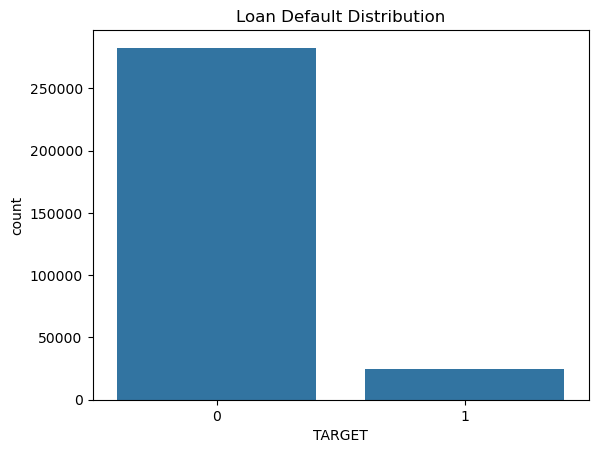

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x= 'TARGET', data=df)
plt.title("Loan Default Distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

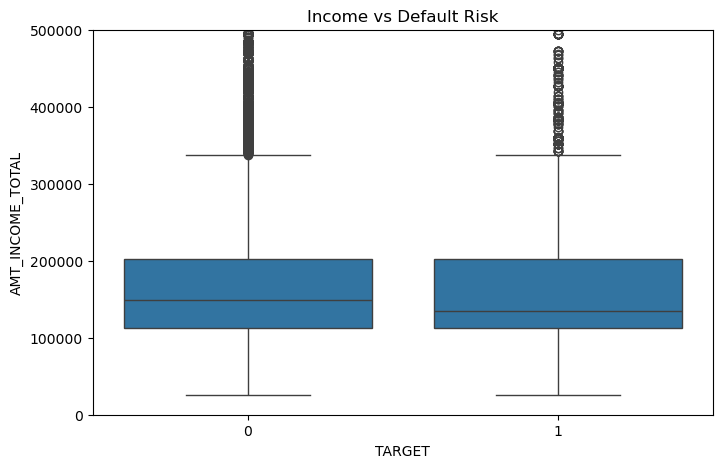

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(x="TARGET", y="AMT_INCOME_TOTAL", data=df)
plt.ylim(0,500000)
plt.title("Income vs Default Risk")
plt.show

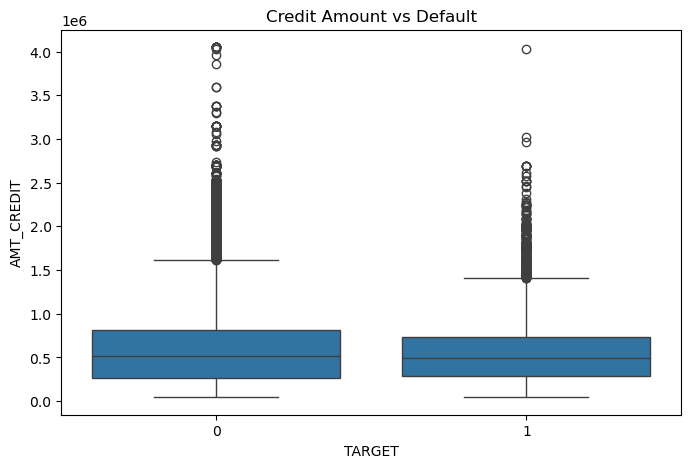

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x = "TARGET" , y = "AMT_CREDIT", data=df)
plt.title("Credit Amount vs Default")
plt.show()

In [47]:
missing = df.isnull().sum()
missing_percent = (missing/ len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percent Missing": missing_percent
})
missing_df = missing_df.sort_values("Percent Missing", ascending = False)
missing_df.head(20)

,Missing Values,Percent Missing
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


In [49]:
columns_to_drop = missing_df[missing_df["Percent Missing"] > 50].index
df = df.drop(columns=columns_to_drop)
print("Remaining columns:", df.shape[1])

Remaining columns: 81


In [51]:
categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.select_dtypes(exclude=['object']).columns
print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Categorical columns: 13
Numeric columns: 68


In [55]:
#Fill missing values with median cause median is robust to outliers#
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [59]:
#Filling the categorical variables with mode#
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [61]:
df = pd.get_dummies(df, columns = categorical_cols, drop_first =True)

In [135]:
df = df.drop(columns=["SK_ID_CURR"])

In [137]:
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

In [139]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [141]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\mikym\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [142]:
y_pred = model.predict(X_test)

In [143]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56553     1]
 [ 4949     0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.00      0.00      0.00      4949

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [148]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [150]:
y_pred = model.predict(X_test)

In [151]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[38780 17774]
 [ 1624  3325]]
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56554
           1       0.16      0.67      0.26      4949

    accuracy                           0.68     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.68      0.76     61503



In [155]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [156]:
rf_pred = rf_model.predict(X_test)

In [157]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[56553     1]
 [ 4944     5]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.83      0.00      0.00      4949

    accuracy                           0.92     61503
   macro avg       0.88      0.50      0.48     61503
weighted avg       0.91      0.92      0.88     61503



In [161]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [163]:
from sklearn.metrics import roc_auc_score

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest ROC-AUC: 0.7091447736677523


In [165]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(20)

EXT_SOURCE_2                    0.061539
EXT_SOURCE_3                    0.057725
DAYS_BIRTH                      0.043501
DAYS_ID_PUBLISH                 0.042847
DAYS_REGISTRATION               0.042379
AMT_ANNUITY                     0.039218
DAYS_LAST_PHONE_CHANGE          0.038088
DAYS_EMPLOYED                   0.037551
AMT_CREDIT                      0.036941
AMT_INCOME_TOTAL                0.032729
REGION_POPULATION_RELATIVE      0.032133
AMT_GOODS_PRICE                 0.031693
HOUR_APPR_PROCESS_START         0.028772
TOTALAREA_MODE                  0.022406
AMT_REQ_CREDIT_BUREAU_YEAR      0.020542
YEARS_BEGINEXPLUATATION_AVG     0.017881
YEARS_BEGINEXPLUATATION_MEDI    0.017871
YEARS_BEGINEXPLUATATION_MODE    0.017592
OBS_30_CNT_SOCIAL_CIRCLE        0.016357
OBS_60_CNT_SOCIAL_CIRCLE        0.016291
dtype: float64

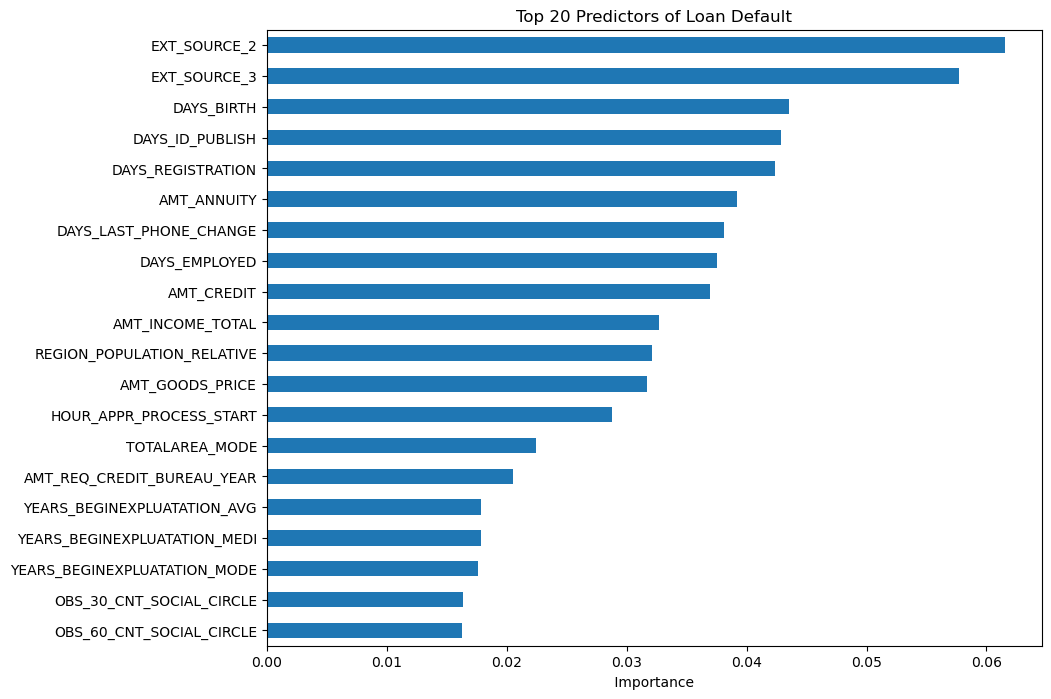

In [167]:
import matplotlib.pyplot as plt
top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind='barh')

plt.title("Top 20 Predictors of Loan Default")
plt.xlabel(" Importance ")
plt.show()

In [169]:
from sklearn.metrics import roc_auc_score

log_prob = model.predict_proba(X_test)[:,1]

rf_prob = rf_model.predict_proba(X_test)[:,1]

log_auc = roc_auc_score(y_test, log_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Logistic Regression ROC-AUC:", log_auc)
print("Random Forest ROC-AUC:", rf_auc)

Logistic Regression ROC-AUC: 0.7439329404077619
Random Forest ROC-AUC: 0.7091447736677523


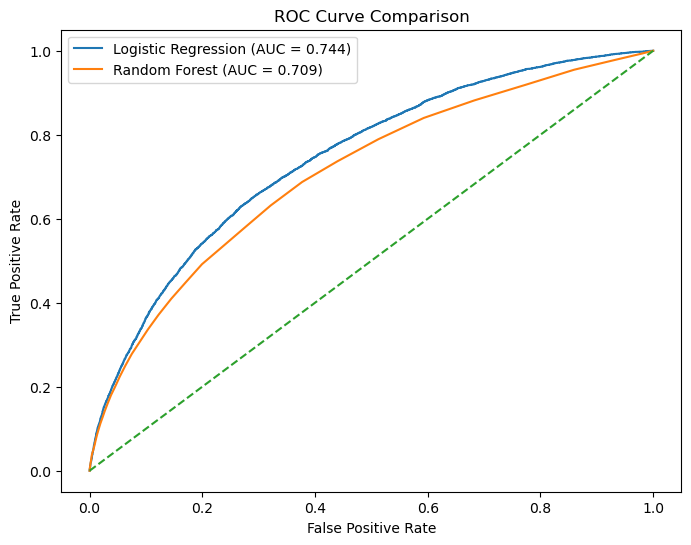

In [171]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()